In [5]:
names_executionsCG = ["Elastic_CG_h0.0625_dt3.562228534370604e-07_T2.0",
                          "Elastic_CG_h0.03125_dt3.5521574925923005e-07_T2.0",
                          "Elastic_CG_h0.015625_dt3.5470262904624406e-07_T2.0",
                          "Elastic_CG_h0.0078125_dt3.54443477457167e-07_T2.0",
                          "Elastic_CG_h0.00390625_dt3.543127098382115e-07_T2.0"]
names_executionsDG_LXF = ["Elastic_DG_h0.0625_dt1.6329081033994441e-06_T2.0",
                          "Elastic_DG_h0.03125_dt1.4787590205678214e-06_T2.0",
                          "Elastic_DG_h0.015625_dt1.3753853551623507e-06_T2.0",
                          "Elastic_DG_h0.0078125_dt1.2942976299612496e-06_T2.0",
                          "Elastic_DG_h0.00390625_dt1.2364333752401535e-06_T2.0"]
names_executionsDG_HLL = ["Elastic_DG_h0.0625_dt4.0155992808710295e-06_T2.0",
                          "Elastic_DG_h0.03125_dt3.83844054230309e-06_T2.0",
                          "Elastic_DG_h0.015625_dt3.631650142832399e-06_T2.0",
                          "Elastic_DG_h0.0078125_dt3.3643811230277265e-06_T2.0",
                          "Elastic_DG_h0.00390625_dt9.863108243468588e-07_T2.0"]
names_executions = [names_executionsCG, names_executionsDG_LXF, names_executionsDG_HLL]

In [2]:
import os
import numpy as np

In [3]:
import ufl
from dolfinx import fem, mesh
from basix.ufl import element
from mpi4py import MPI

In [4]:
import dolfinx
print(dolfinx.__version__)

0.9.0


In [6]:
path1 = os.path.join("results","test")
paths_method = np.array([os.path.join("CG"), os.path.join("DG", "LxF"), os.path.join("DG", "HLL")])
path_data = os.path.join("data")

In [8]:
solutions_global_arr = np.empty(3,dtype=object)
for method_e in range(3):
    name_execution_e = names_executions[method_e]
    path_method_e = paths_method[method_e]
    solutions_arr = np.empty(5, dtype=object)
    for n_file in range(5):
        solution_i = np.empty(3, dtype=object)
        for n_vessel in range(3):
            name_vessel = f"vessel_{n_vessel}_solutions.npz"
            path = os.path.join(path1, path_method_e, name_execution_e[n_file], path_data, name_vessel)
            arr = np.load(path)
            solution_i[n_vessel] = arr
        solutions_arr[n_file] = solution_i
    solutions_global_arr[method_e] = solutions_arr

In [10]:
L_vessels = [1,1,2]
Ns = np.array([16, 32, 64, 128, 256])
hs = 1/Ns
ts = np.arange(0,2,0.001)
variables = ['area', 'flux']

In [17]:
solutions_global = np.empty(3,dtype=object)
for method_e in range(3):
    solutions = np.empty(len(hs), dtype=object)
    solutions_arr = solutions_global_arr[method_e]
    for n_file in range(len(hs)):
        solution_i = np.empty(len(L_vessels), dtype=object)
        h = hs[n_file]
        for n_vessel in range(len(L_vessels)):
            n = int(L_vessels[n_vessel] / h)
            mesh_sparse = mesh.create_interval(MPI.COMM_WORLD, n, (0, L_vessels[n_vessel]))
            h = h
            if method_e == 0:
                elem = element("Lagrange", mesh_sparse.topology.cell_name(), 1, shape=(2, ), discontinuous=False)
            else:
                elem = element("Lagrange", mesh_sparse.topology.cell_name(), 1, shape=(2, ), discontinuous=True)
            V = fem.functionspace(mesh_sparse, elem)
            solution_i_t = np.empty(len(ts), dtype=object)
            for t in range(len(ts)):
                u_t = fem.Function(V)
                for n_variable in range(len(variables)):
                    sol_arr = solutions_arr[n_file][n_vessel][variables[n_variable]][t]
                    u_t.x.array[n_variable::2] = sol_arr
                solution_i_t[t] = u_t
            solution_i[n_vessel] = solution_i_t
        solutions[n_file] = solution_i
    solutions_global[method_e] = solutions
            

In [68]:
def create_interpolation(u_coarse, u_fine):
    topol = u_fine.function_space.mesh.topology
    num_cells = topol.index_map(topol.dim).size_local
    # 2. Create an array of all cell indices
    cells = np.arange(num_cells, dtype=np.int64)
    nmm_data = fem.create_interpolation_data(
        u_fine.function_space,
        u_coarse.function_space,
        cells)
    u_coarse_interp = fem.Function(u_fine.function_space)
    u_coarse_interp.interpolate_nonmatching(u_coarse, cells, interpolation_data=nmm_data)
    return u_coarse_interp

In [69]:
richardson_global = np.empty(3,dtype=object)
for method_e in range(3):
    richardson_extrap = np.empty(len(L_vessels), dtype=object)
    for n_vessel in range(len(L_vessels)):
        richardson_extrap_i = np.empty(len(ts),dtype=object)
        for t in range(len(ts)):
            u_128 = solutions[-2][n_vessel][t]
            u_256 = solutions[-1][n_vessel][t]
            u_128_interp = create_interpolation(u_128, u_256)
            richardson_extrap_i_t = fem.Function(u_256.function_space)
            richardson_extrap_i_t.x.array[:] = (4.0 * u_256.x.array - u_128_interp.x.array) / 3.0
            richardson_extrap_i[t] = richardson_extrap_i_t
        richardson_extrap[n_vessel] = richardson_extrap_i
    richardson_global[method_e] = richardson_extrap
        

In [45]:
spatial_errors = np.empty((3, len(hs)-1, len(L_vessels), len(ts), 2), dtype=np.float64)
for method_e in range(3):
    solutions = solutions_global[method_e]
    richardson_extrap = richardson_global[method_e]
    for n_file in range(len(hs)-1):
        for n_vessel in range(len(L_vessels)):
            for t in range(len(ts)):
                u_coarse = solutions[n_file][n_vessel][t]
                u_fine = richardson_extrap[n_vessel][t]
                u_coarse_interp = create_interpolation(u_coarse, u_fine)
                error_func = fem.Function(u_fine.function_space)
                error_func.x.array[:] = (u_fine.x.array - u_coarse_interp.x.array)
                e_A, e_Q = ufl.split(error_func)
                L2_form_A = fem.form(ufl.inner(e_A, e_A) * ufl.dx)
                L2_error_A = np.sqrt(fem.assemble_scalar(L2_form_A))
                L2_form_Q = fem.form(ufl.inner(e_Q, e_Q) * ufl.dx)
                L2_error_Q = np.sqrt(fem.assemble_scalar(L2_form_Q))
                spatial_errors[method_e, n_file, n_vessel, t, :] = [L2_error_A, L2_error_Q]

In [46]:
errors = spatial_errors.max(axis=2)

In [47]:
errors.shape

(3, 4, 2000, 2)

In [62]:
method_n = 1
area_errors = errors[method_n,:,:,0]
flux_errors = errors[method_n,:,:,1]

In [63]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

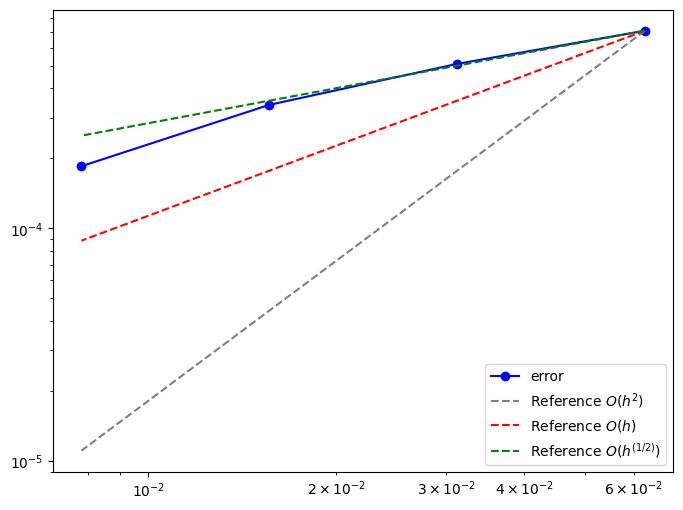

In [64]:
plt.figure(figsize=(8, 6))
h_square = area_errors[0,0] / (hs[0]**2)  * (hs[:len(hs)-1]**2)
h_scaled = area_errors[0,0] / (hs[0])  * (hs[:len(hs)-1])
h_1_2 = area_errors[0,0] / (hs[0]**(1/2))  * (hs[:len(hs)-1]**(1/2))
plt.loglog(hs[:len(hs)-1],area_errors[:,0], marker='o', linestyle='-', color='blue', label='error')
plt.loglog(hs[:len(hs)-1], h_square, linestyle='--', color='gray', label='Reference $O(h^2)$')
plt.loglog(hs[:len(hs)-1], h_scaled, linestyle='--', color='red', label='Reference $O(h)$')
plt.loglog(hs[:len(hs)-1], h_1_2, linestyle='--', color='green', label='Reference $O(h^{(1/2)})$')
plt.legend()
plt.show